<a href="https://colab.research.google.com/github/akkshatk-92/100-Days-of-Machine-Leaning/blob/main/Decision_trees_using_GridSearchCV/Decision_trees_using_GridSearchCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')

Saving diabetes.csv to diabetes.csv
Uploaded file: diabetes.csv


In [ ]:
import pandas as pd
df=pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
X = df.iloc[:, :-1].values  # All columns except the last one (features)
y = df.iloc[:, -1].values   # Only the last column (target)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X=sc.fit_transform(X)
print(X)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion='gini',max_depth=None,random_state=42)
clf.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred=clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6948051948051948

In [ ]:
print("Train Accuracy:", clf.score(X_train, y_train))
print("Test Accuracy:", clf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.6948051948051948


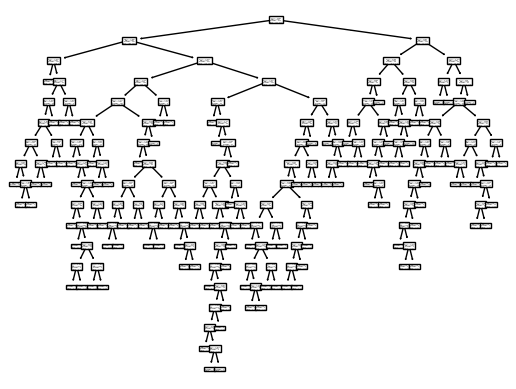

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clf)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       103
           1       0.54      0.57      0.55        51

    accuracy                           0.69       154
   macro avg       0.66      0.66      0.66       154
weighted avg       0.70      0.69      0.70       154



In [ ]:
param_dist={
    'criterion':['gini','entropy'],
    'max_depth':[None,2,3,4,5,6,7,8,9,10],
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=clf,param_grid=param_dist,cv=10)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
grid_search.best_score_

np.float64(0.7441036488630355)

**Accuracy achieve 74.4%**

In [ ]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 4}